In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

# Style settings - makes plots look clean
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 11

random.seed(42)
np.random.seed(42)

print("Day 5 - Matplotlib & EDA")
print(f"Matplotlib imported successfully")

Day 5 - Matplotlib & EDA
Matplotlib imported successfully


In [3]:
# Simulate 30 days of RAG pipeline data
n_docs = 50
sources = ["rag_paper.pdf", "llm_guide.pdf", "vector_db.pdf", "fine_tuning.pdf"]
statuses = ["embedded", "embedded", "embedded", "failed", "pending"]# weighted
 
data = {
    "doc_id" : [f"doc_{i:03d}" for i in range(n_docs)],
    "source" : [random.choice(sources) for _ in range(n_docs)],
    "status" : [random.choice(statuses) for _ in range(n_docs)],
    "word_count" : [random.randint(50, 600) for _ in range(n_docs)],
    "similarity_score": [round(random.uniform(0.1, 0.99), 4) for _ in range(n_docs)],
    "page_number" : [random.randint(1,100) for _ in range(n_docs)],
    "created_at" : [
        datetime.now() - timedelta(days=random.randint(0,30))
        for _ in range(n_docs)
    ]
}

df = pd.DataFrame(data)

# Add quality column
def get_quality(score):
    if score >= 0.7:
        return "high"
    elif score >= 0.4:
        return "medium"
    else:
        return "low"
    
df["quality"] = df["similarity_score"].apply(get_quality)

print(f"Dataset shape: {df.shape}")
print(f"\nStatus distribution:\n{df['status'].value_counts()}")
print(f"\nQuanity distribution:\n{df['quality'].value_counts()}")

Dataset shape: (50, 8)

Status distribution:
status
embedded    31
failed      10
pending      9
Name: count, dtype: int64

Quanity distribution:
quality
medium    21
low       15
high      14
Name: count, dtype: int64


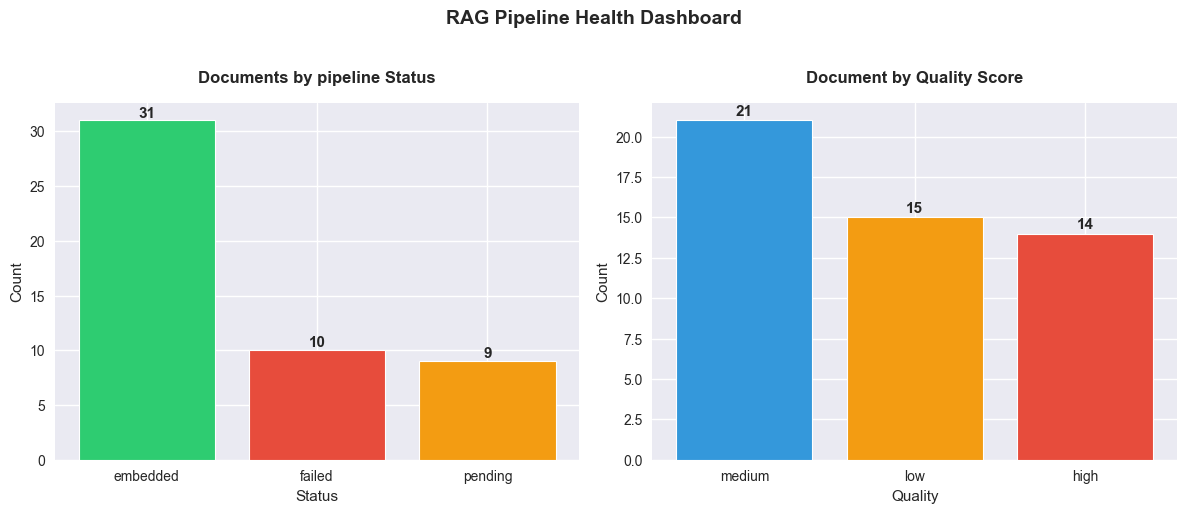

Plot saved as pipeline_status.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - documents by status
status_counts = df["status"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#f39c12"] #green, red, amber

axes[0].bar(status_counts.index, status_counts.values , color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Documents by pipeline Status", fontweight="bold", pad=15)
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")

# Add value labels on top of each bar
for i, (status, count) in enumerate(status_counts.items()):
    axes[0].text(i, count+0.3, str(count), ha="center", fontweight = "bold")

# Plot 2 - documents by quality
quality_counts = df["quality"].value_counts()
quality_colors = ["#3498db", "#f39c12", "#e74c3c"] # blue, amber, red

axes[1].bar(quality_counts.index, quality_counts.values, color=quality_colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("Document by Quality Score", fontweight="bold", pad=15)
axes[1].set_xlabel("Quality")
axes[1].set_ylabel("Count")

for i, (quality, count) in enumerate(quality_counts.items()):
    axes[1].text(i, count + 0.3, str(count), ha="center", fontweight="bold")

plt.suptitle("RAG Pipeline Health Dashboard", fontsize =14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pipeline_status.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as pipeline_status.png")

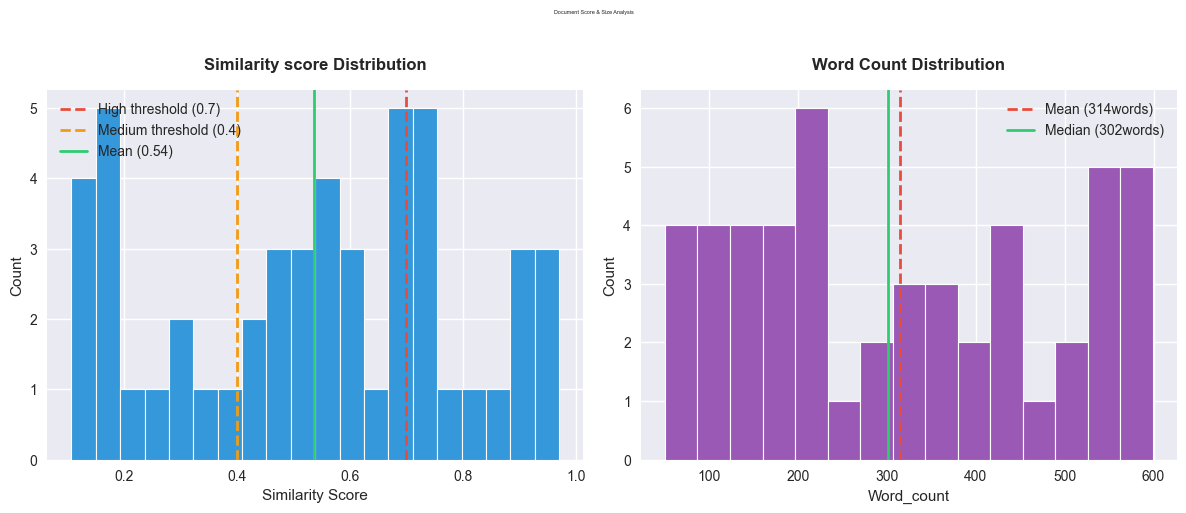

Plot saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - similarity score distribution
axes[0].hist(
    df["similarity_score"],
    bins=20,
    color="#3498db",
    edgecolor="white",
    linewidth= 0.8
)

axes[0].axvline(x=0.7, color="#e74c3c", linestyle="--", linewidth=2, label="High threshold (0.7)")
axes[0].axvline(x=0.4, color="#f39c12", linestyle="--", linewidth=2, label="Medium threshold (0.4)")
axes[0].axvline(x=df["similarity_score"].mean(), color="#2ecc71", linestyle="-", linewidth=2, label=f"Mean ({df['similarity_score'].mean():.2f})")
axes[0].set_title("Similarity score Distribution", fontweight="bold", pad=15)
axes[0].set_xlabel("Similarity Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2 - word count distribution
axes[1].hist(
    df["word_count"],
    bins=15,
    color="#9b59b6",
    edgecolor="white",
    linewidth=0.8
)
axes[1].axvline(x=df["word_count"].mean(), color="#e74c3c", linestyle="--", linewidth=2, label=f"Mean ({df['word_count'].mean():.0f}words)")
axes[1].axvline(x=df["word_count"].median(), color="#2ecc71", linestyle="-", linewidth=2, label=f"Median ({df['word_count'].median():.0f}words)")
axes[1].set_title("Word Count Distribution", fontweight="bold", pad=15)
axes[1].set_xlabel("Word_count")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Document Score & Size Analysis", fontsize=4, fontweight=14, y=1.02)
plt.tight_layout()
plt.savefig("Score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")



C:\Users\jkc90\AppData\Local\Temp\ipykernel_25012\2322230958.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


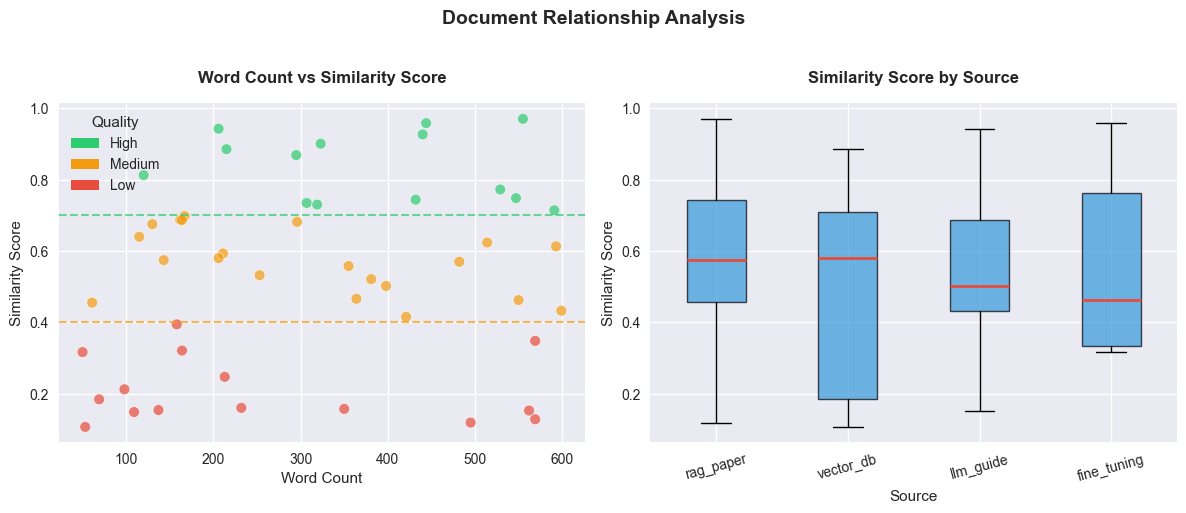

Plot saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - word count vs similarity score
colors_map = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
colors = df["quality"].map(colors_map)

scatter =axes[0].scatter(
    df["word_count"],
    df["similarity_score"],
    c=colors,
    alpha=0.7,
    s=60,
    edgecolors="white",
    linewidth=0.5
)

axes[0].axhline(y=0.7, color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].axhline(y=0.4, color="#f39c12", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].set_title("Word Count vs Similarity Score", fontweight="bold", pad=15)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Similarity Score")

#Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="High"),
    Patch(facecolor="#f39c12", label="Medium"),
    Patch(facecolor="#e74c3c", label="Low")
]
axes[0].legend(handles=legend_elements, title="Quality")

#Plot 2 - similarity score by scource (box plot)
sources = df["source"].unique()
score_by_source = [df[df["source"] == s]["similarity_score"].values for s in sources]

bp = axes[1].boxplot(
    score_by_source,
    labels=[s.replace(".pdf" , "") for s in sources],
    patch_artist=True,
    boxprops=dict(facecolor= "#3498db", alpha=0.7),
    medianprops= dict(color="#e74c3c", linewidth=2)
)

axes[1].set_title("Similarity Score by Source", fontweight="bold", pad=15)
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Similarity Score")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Document Relationship Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("relationship_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

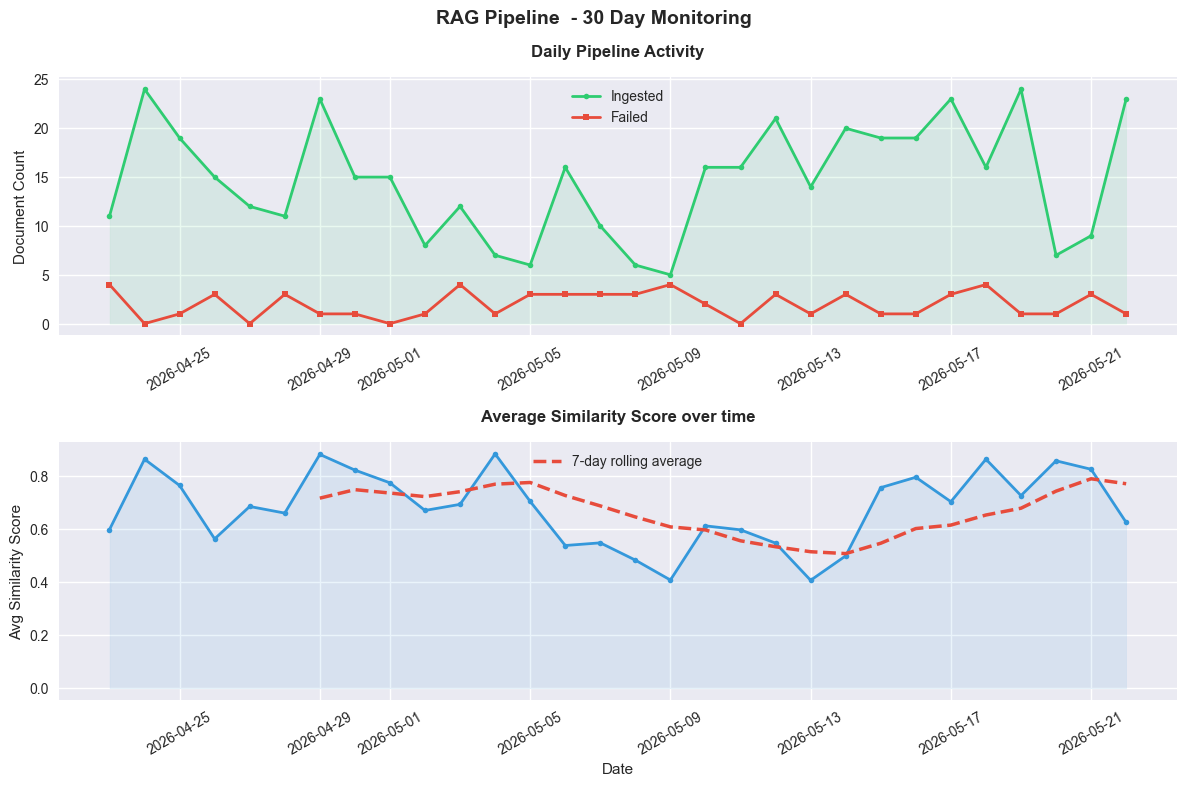

Plot saved


In [7]:
# Simulate daily ingestion stats over 30 days
days = pd.date_range(start ="2026-04-23", periods=30, freq="D")

np.random.seed(42)
daily_data = pd.DataFrame({
    "date": days,
    "docs_ingested": np.random.randint(5, 25, size=30),
    "docs_failed": np.random.randint(0, 5, size=30),
    "avg_score": np.random.uniform(0.4, 0.9, size=30).round(3)
})

# Calculate cumulative docs
daily_data["cumulative_docs"] = daily_data["docs_ingested"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12,8))

# Plot 1 - daily ingestion and failures
axes[0].plot(
    daily_data["date"],
    daily_data["docs_ingested"],
    color="#2ecc71",
    linewidth =2,
    marker="o",
    markersize=4,
    label="Ingested"
)
axes[0].fill_between(
    daily_data["date"],
    daily_data["docs_ingested"],
    alpha=0.1,
    color="#2ecc71"
)
axes[0].plot(
    daily_data["date"],
    daily_data["docs_failed"],
    color="#e74c3c",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Failed"
)
axes[0].set_title("Daily Pipeline Activity", fontweight="bold", pad=15)
axes[0].set_ylabel("Document Count")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Plot 2 - average similarity score over time
axes[1].plot(
    daily_data["date"],
    daily_data["avg_score"],
    color="#3498db",
    linewidth=2,
    marker="o",
    markersize=4
)
axes[1].fill_between(
    daily_data["date"],
    daily_data["avg_score"],
    alpha=0.1,
    color="#3498db"
)

# Add rolling average
rolling_avg = daily_data["avg_score"].rolling(window=7).mean()
axes[1].plot(
    daily_data["date"],
    rolling_avg,
    color="#e74c3c",
    linewidth= 2.5,
    linestyle="--",
    label="7-day rolling average"
)
axes[1].set_title("Average Similarity Score over time", fontweight="bold", pad=15)
axes[1].set_ylabel("Avg Similarity Score")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("RAG Pipeline  - 30 Day Monitoring", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pipeline_monitoring.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

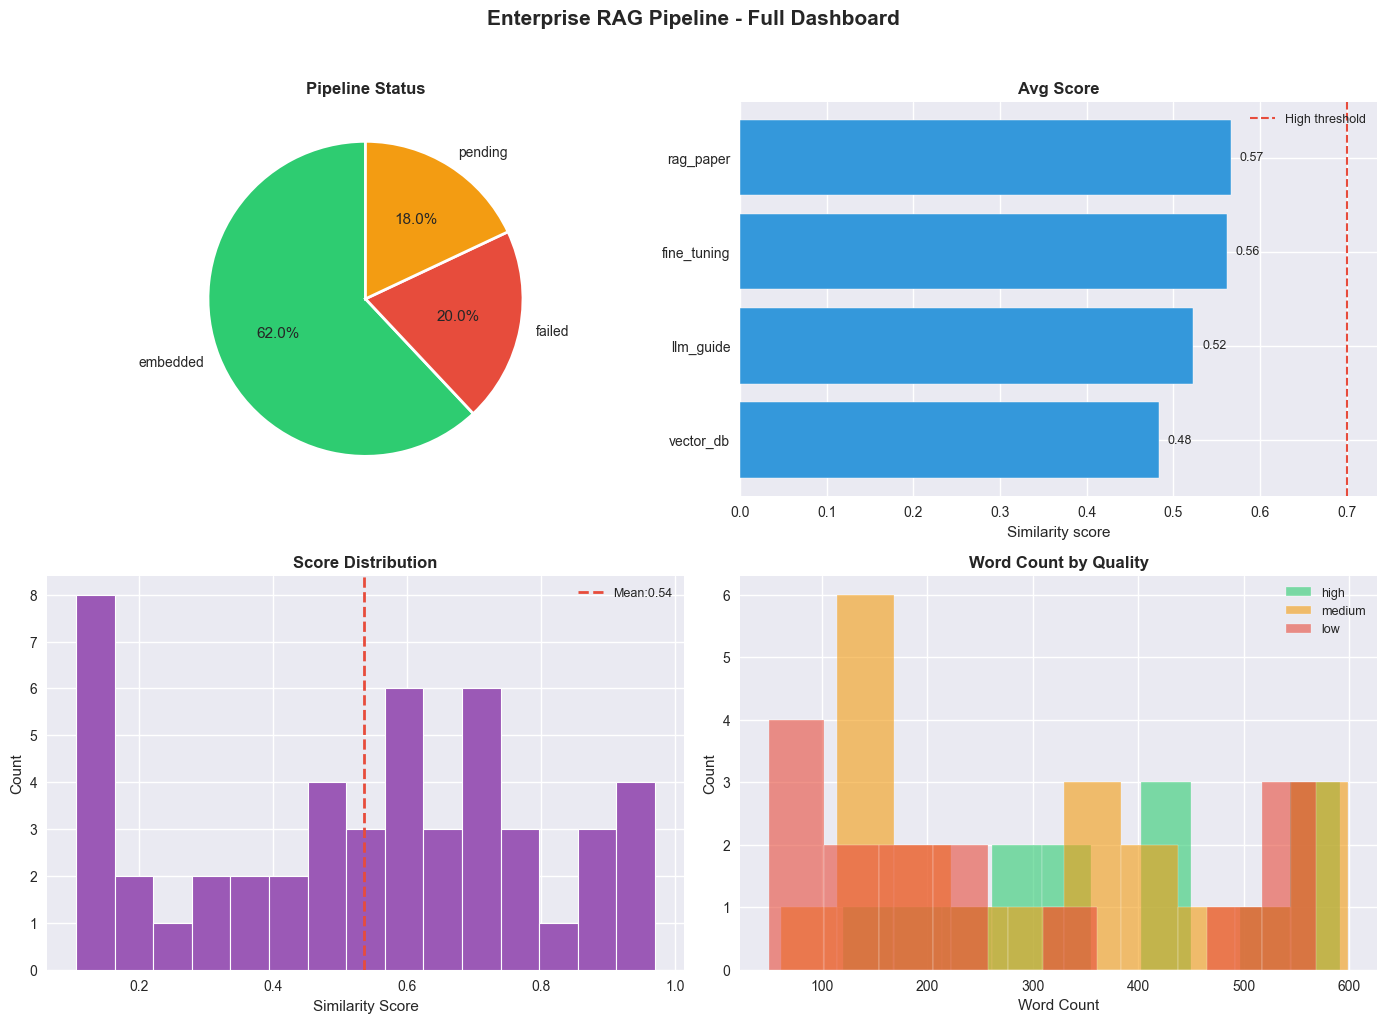

Dashboard saved as full_dashboard.png


In [8]:
fig =plt.figure(figsize=(14, 10))

# Create a 2X2 grid
ax1 = fig.add_subplot(2, 2, 1) # top left
ax2 = fig.add_subplot(2, 2, 2) # top right
ax3 = fig.add_subplot(2, 2, 3) # bottom left
ax4 = fig.add_subplot(2, 2, 4) # bottom right

# --- Plot 1: Status pie chart ----
status_counts = df["status"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
ax1.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
ax1.set_title("Pipeline Status", fontweight="bold")

# ---- Plot 2: Avg score per source -----
avg_by_source = df.groupby("source")["similarity_score"].mean().sort_values()
bars = ax2.barh(
    [s.replace(".pdf", "") for s in avg_by_source.index],
    avg_by_source.values,
    color="#3498db",
    edgecolor="white"
)
ax2.axvline(x=0.7, color="#e74c3c", linestyle="--", linewidth=1.5, label="High threshold")
ax2.set_title("Avg Score", fontweight="bold")
ax2.set_xlabel("Similarity score")
ax2.legend(fontsize=9)

for bar, val in zip(bars, avg_by_source.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=9)
    
# --- Plot 3: Score histogram ----
ax3.hist(df["similarity_score"], bins=15, color="#9b59b6",
         edgecolor="white", linewidth=0.8)
ax3.axvline(x=df["similarity_score"].mean() , color="#e74c3c", 
            linestyle="--", linewidth=2,
            label=f"Mean:{df['similarity_score'].mean():.2f}")
ax3.set_title("Score Distribution", fontweight="bold")
ax3.set_xlabel("Similarity Score")
ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

# ---- Plot 4: Word count by quality -----
quality_order = ["high", "medium", "low"]
quality_colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for quality, color in zip(quality_order, quality_colors):
    subset = df[df["quality"] == quality]["word_count"]
    ax4.hist(subset, bins=10, alpha=0.6, color=color,
             label=quality, edgecolor="white")
ax4.set_title("Word Count by Quality", fontweight="bold")
ax4.set_xlabel("Word Count")
ax4.set_ylabel("Count")
ax4.legend(fontsize=9)

plt.suptitle("Enterprise RAG Pipeline - Full Dashboard",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("full_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as full_dashboard.png")
